# Task 9 - Industrial Predictive Maintenance

Predicting machine failures from sensor readings, while keeping false alarms as low as possible.
Dataset: AI4I 2020 Predictive Maintenance Dataset by Stephan Matzka (Kaggle / UCI), 10,000 machine readings.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Loading the data

In [ ]:
df = pd.read_csv("ai4i2020.csv")
print(df.shape)
df.head()

(10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 2. Understanding the data
No missing values or duplicates. Only 339 of 10,000 readings (3.4%) are failures, so accuracy alone is not useful here.

In [ ]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Missing values: 0
Duplicate rows: 0


In [ ]:
df["Machine failure"].value_counts()

,count
Machine failure,
0,9661
1,339


In [ ]:
df[["TWF", "HDF", "PWF", "OSF", "RNF"]].sum()

,0
TWF,46
HDF,115
PWF,95
OSF,98
RNF,19


In [ ]:
df["Type"].value_counts()

,count
Type,
L,6000
M,2997
H,1003


## 3. Feature engineering
I renamed the columns because XGBoost does not accept [ ] in column names. Then I created three features based on how the machine fails:
- Temp_diff: a small difference between process and air temperature means heat cannot escape (overheating)
- Power: torque x speed in watts (power failure)
- Wear_x_torque: a worn tool under high force (overstrain)

Type has a natural order (L < M < H), so I encoded it as 0, 1, 2.

In [ ]:
df = df.rename(columns={
    "Air temperature [K]": "Air_temp",
    "Process temperature [K]": "Process_temp",
    "Rotational speed [rpm]": "Speed",
    "Torque [Nm]": "Torque",
    "Tool wear [min]": "Tool_wear",
})

In [ ]:
df["Temp_diff"] = df["Process_temp"] - df["Air_temp"]
df["Power"] = df["Torque"] * df["Speed"] * 2 * np.pi / 60
df["Wear_x_torque"] = df["Tool_wear"] * df["Torque"]

df["Type"] = df["Type"].map({"L": 0, "M": 1, "H": 2})

df[["Temp_diff", "Power", "Wear_x_torque"]].describe()

,Temp_diff,Power,Wear_x_torque
count,10000.000000,10000.000000,10000.000000
mean,10.000630,6279.744953,4314.664550
std,1.001094,1067.418295,2826.567692
min,7.600000,1148.440610,0.000000
25%,9.300000,5561.184484,1963.650000
50%,9.800000,6271.027344,4012.950000
75%,11.000000,7003.002724,6279.000000
max,12.100000,10469.923005,16497.000000


## 4. Train/test split
I removed the IDs and the five failure type columns (TWF, HDF, PWF, OSF, RNF), because they are only known after a failure and would leak the answer. 80% training and 20% testing, stratified.

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["UDI", "Product ID", "Machine failure", "TWF", "HDF", "PWF", "OSF", "RNF"])
y = df["Machine failure"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Features:", X.columns.tolist())
print("Training rows:", len(X_train), "| Test rows:", len(X_test))
print("Failures in test set:", y_test.sum())

Features: ['Type', 'Air_temp', 'Process_temp', 'Speed', 'Torque', 'Tool_wear', 'Temp_diff', 'Power', 'Wear_x_torque']
Training rows: 8000 | Test rows: 2000
Failures in test set: 68


## 5. Random Forest vs XGBoost
FDR (False Discovery Rate) = false alarms / all alarms. A false alarm stops production for nothing, so this is the main metric.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

def report(name, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    fdr = fp / (tp + fp)
    print(f"{name}: accuracy {accuracy_score(y_test, y_pred):.4f} | precision {precision:.3f} | "
          f"recall {recall:.3f} | FDR {fdr:.3f} | false alarms {fp} | missed failures {fn}")

rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
report("Random Forest", rf.predict(X_test))

xgb = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)
report("XGBoost      ", xgb.predict(X_test))

Random Forest: accuracy 0.9930 | precision 0.966 | recall 0.824 | FDR 0.034 | false alarms 2 | missed failures 12
XGBoost      : accuracy 0.9905 | precision 0.930 | recall 0.779 | FDR 0.070 | false alarms 4 | missed failures 15


## 6. Threshold tuning
The model predicts a probability of failure. Raising the threshold means it only raises an alarm when it is more sure, which reduces false alarms but misses more failures.

In [ ]:
rf_proba = rf.predict_proba(X_test)[:, 1]

for threshold in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred = (rf_proba >= threshold).astype(int)
    report(f"Threshold {threshold}", y_pred)

Threshold 0.2: accuracy 0.9870 | precision 0.784 | recall 0.853 | FDR 0.216 | false alarms 16 | missed failures 10
Threshold 0.3: accuracy 0.9910 | precision 0.903 | recall 0.824 | FDR 0.097 | false alarms 6 | missed failures 12
Threshold 0.4: accuracy 0.9930 | precision 0.966 | recall 0.824 | FDR 0.034 | false alarms 2 | missed failures 12
Threshold 0.5: accuracy 0.9930 | precision 0.966 | recall 0.824 | FDR 0.034 | false alarms 2 | missed failures 12
Threshold 0.6: accuracy 0.9920 | precision 0.964 | recall 0.794 | FDR 0.036 | false alarms 2 | missed failures 14
Threshold 0.7: accuracy 0.9910 | precision 0.981 | recall 0.750 | FDR 0.019 | false alarms 1 | missed failures 17


## 7. Feature importance and sensor correlation (bonus)

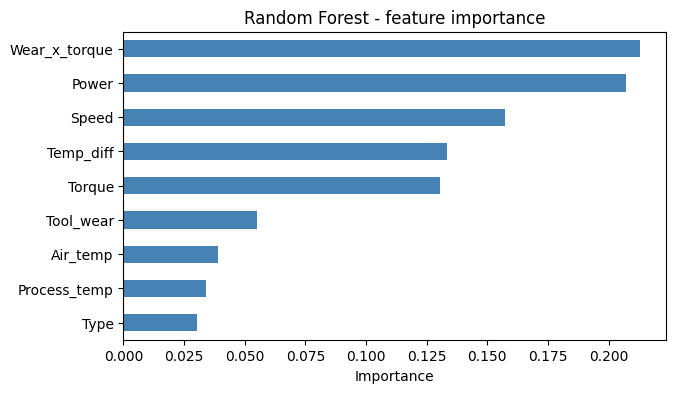

Temp_diff       -0.112
Speed           -0.044
Process_temp     0.036
Air_temp         0.083
Tool_wear        0.105
Power            0.176
Wear_x_torque    0.190
Torque           0.191
Name: Machine failure, dtype: float64


In [ ]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
importances.plot(kind="barh", color="steelblue", figsize=(7, 4))
plt.title("Random Forest - feature importance")
plt.xlabel("Importance")
plt.show()

sensors = ["Air_temp", "Process_temp", "Speed", "Torque", "Tool_wear",
           "Temp_diff", "Power", "Wear_x_torque"]
print(df[sensors + ["Machine failure"]].corr()["Machine failure"].drop("Machine failure").sort_values().round(3))

## Conclusion

The dataset has 10,000 machine readings and only 3.4% of them are failures. A model that
always predicts no failure would already be 96.6% accurate, so I focused on precision,
recall and the False Discovery Rate (FDR) instead.

I removed the five failure type columns because they would leak the answer, and created
three new features: temperature difference, power and tool wear x torque.

Results with the default threshold (0.5):
- Random Forest: FDR 0.034 (2 false alarms), recall 0.824, accuracy 99.3%
- XGBoost: FDR 0.070 (4 false alarms), recall 0.779, accuracy 99.05%

Random Forest was better, with fewer false alarms and fewer missed failures.

The task asks to minimise false positives even if accuracy goes down a little, so I tuned
the threshold. With a threshold of 0.7 the Random Forest raised only 1 false alarm
(FDR 0.019, precision 0.981), with accuracy 99.1%. The cost is that it missed 17 failures
instead of 12. If missed failures were more expensive, 0.5 would be a better balance.

The engineered features Wear_x_torque and Power were the most important for the model.
Torque was the sensor most correlated with failure (0.191). The temperature difference
had a negative correlation (-0.112), which means a smaller gap leads to more failures,
matching the overheating failure type.